In [1]:
# ============================================
# DATA UNDERSTANDING PHASE
# ============================================
# Objective:
# Explore the dataset to understand its structure,
# identify key variables, detect issues (missing values,
# outliers), and uncover patterns related to diabetes risk.

In [2]:
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install graphviz
!pip install xgboost

In [2]:
# Import the necessary libraries for data analysis and visualization

import pandas as pd 
import numpy as np
import collections
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import xgboost as xgb
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
import shap
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.stats import randint
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree
from IPython.display import Image
from sklearn.utils.class_weight import compute_sample_weight
import graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from IPython.display import display 
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


# Set default figure size for better readability
plt.rcParams["figure.figsize"] = (10,6)


In [5]:
df = pd.read_csv("../BC_Analytics/Diabetes_and_LifeStyle_Dataset_.csv")
# Load the dataset into a pandas DataFrame and then only display a preview of the records

df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [5]:
df.shape
# Check the number of rows and columns in the dataset

(97297, 31)

In [6]:
df.info()
# Display information about data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

In [7]:
df.describe()
# Generate a summary statistic for numerical features

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,185.984234,54.043537,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,30.222027,0.600039
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,32.013395,10.275047,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,9.065063,0.489892
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [8]:
df.isnull().sum()
# Check for missing values in each column

Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


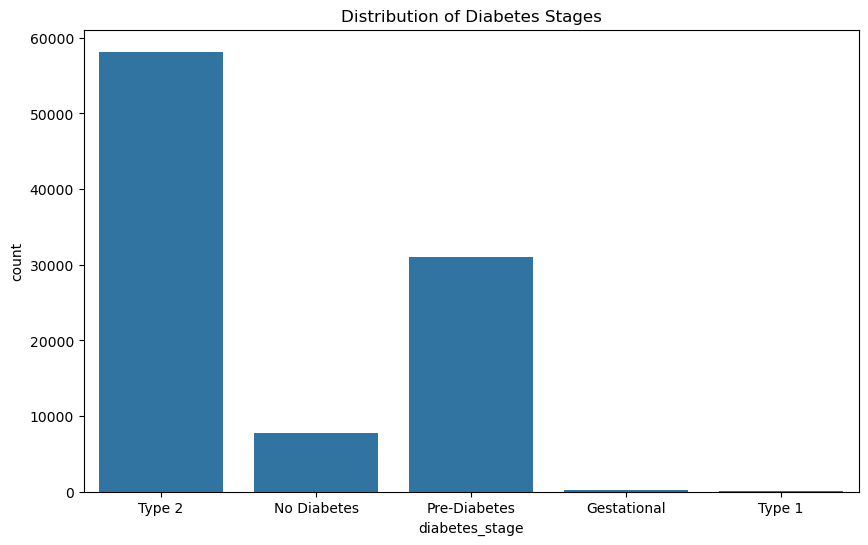

In [9]:
df['diabetes_stage'].value_counts()

sns.countplot(x='diabetes_stage', data=df)
plt.title("Distribution of Diabetes Stages")
plt.show()
# First counts how many records fall into each diabetes stage, then visualizes the distribution of diabetes stages


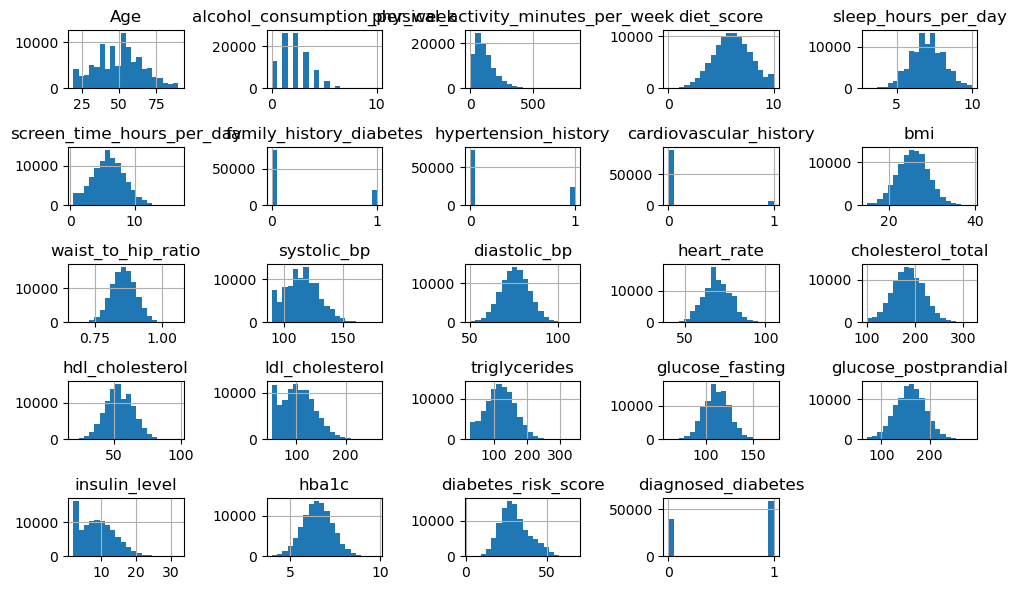

In [10]:
df.hist(bins=20)
plt.tight_layout()
plt.show()
# Plot histograms for all numerical features to understand distributions

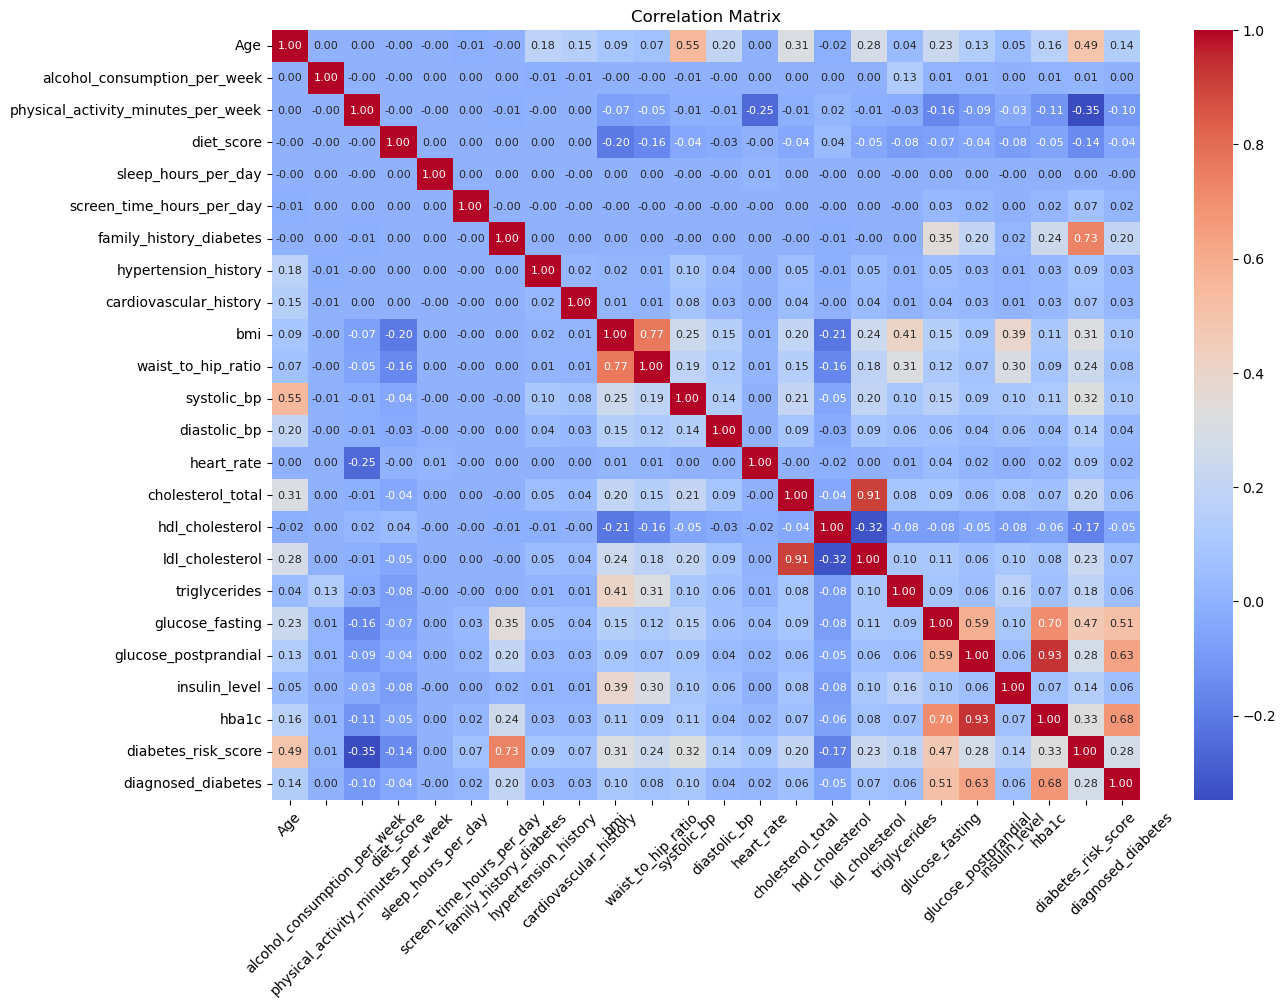

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))  # BIGGER FIGURE
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size":8})
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()
# First computes the correlation matrix for numerical variables, then visualizes correlations using a heatmap


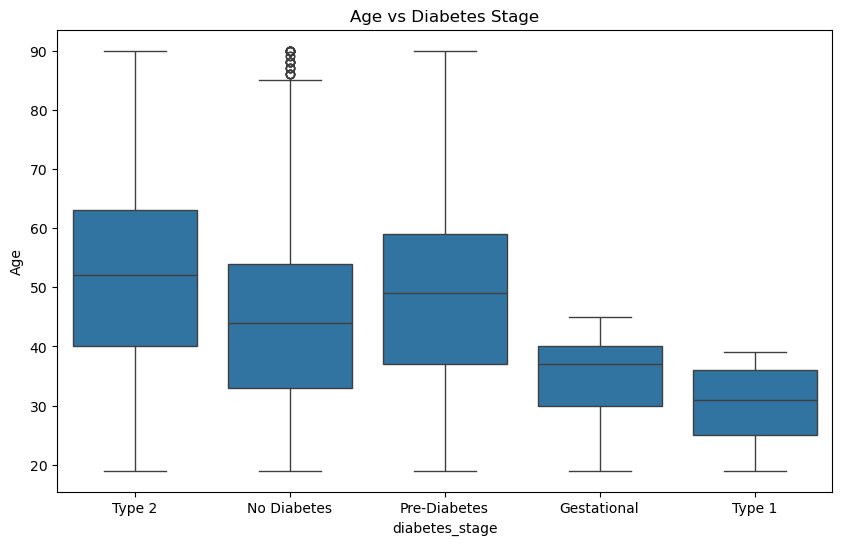

In [12]:
sns.boxplot(x='diabetes_stage', y='Age', data=df)
plt.title("Age vs Diabetes Stage")
plt.show()
# Compare Age distribution across diabetes stages

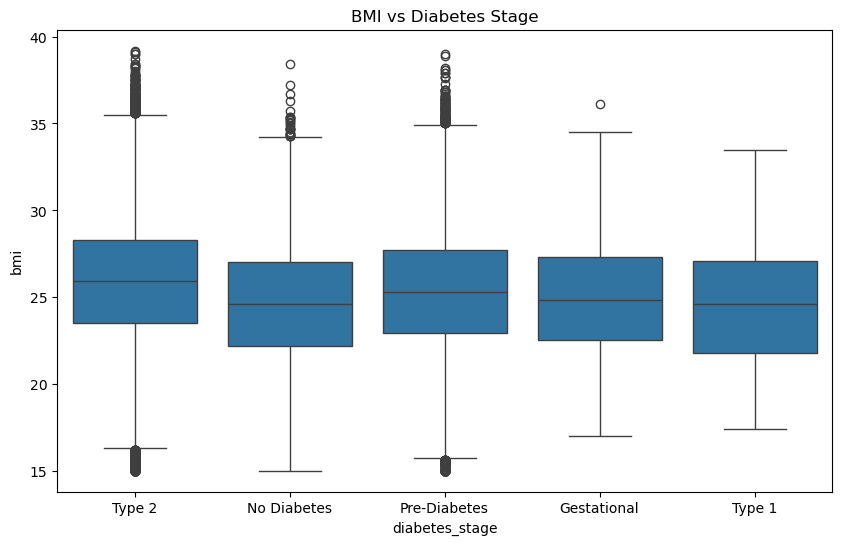

In [13]:
sns.boxplot(x='diabetes_stage', y='bmi', data=df)
plt.title("BMI vs Diabetes Stage")
plt.show()
# Compare BMI distribution across diabetes stages

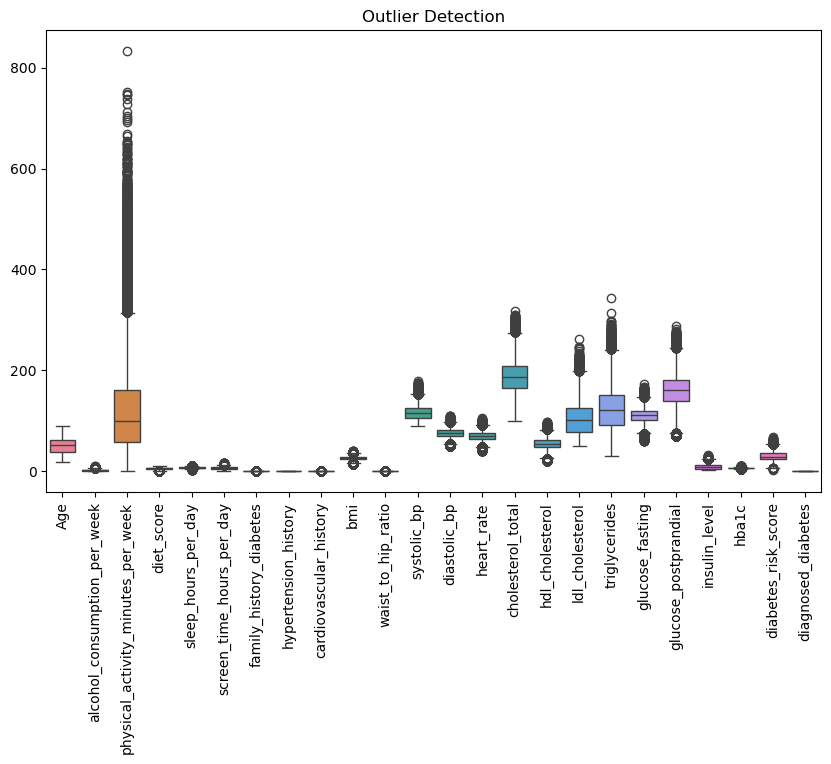

In [14]:
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outlier Detection")

plt.show()
# Detect outliers in numerical features using boxplots

In [15]:
# KEY INSIGHTS
# ============================================
# - The dataset contains multiple health and lifestyle features
# - The target variable (diabetes_stage) shows how patients are distributed across risk levels
# - Certain features, such as BMI and age, appear to vary across different diabetes stages
# - Outliers are present in some numerical variables
# - These findings will guide data preparation and modeling in the next phase



In [16]:
# ============================================
# DATA Preprocessing PHASE
# ============================================
# Objective:
# Data Cleaning 
# Encoding 
# Handle outliers

In [17]:
#check for duplicate values
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Age, gender, ethnicity, education_level, income_level, employment_status, smoking_status, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, family_history_diabetes, hypertension_history, cardiovascular_history, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, glucose_fasting, glucose_postprandial, insulin_level, hba1c, diabetes_risk_score, diabetes_stage, diagnosed_diabetes]
Index: []

[0 rows x 31 columns]


In [18]:
#Data Reduction - removing unecessary columns for modeling(Feature Selection) for predicting diabetes stage 
#diabetes risk score is removed to prevent data leakage, as it is probably calculated from other variables in the dataset.

#features
X = df.drop(['diabetes_risk_score','diabetes_stage','diagnosed_diabetes'], axis=1)
#target
y = df["diabetes_stage"]

#Convert catergorial values 
X = pd.get_dummies(X,drop_first=True)

#model
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
model.fit(X,y)


feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                               feature  importance
21                               hba1c    0.517090
19                glucose_postprandial    0.253168
18                     glucose_fasting    0.172126
6              family_history_diabetes    0.011650
0                                  Age    0.006522
2   physical_activity_minutes_per_week    0.004260
9                                  bmi    0.003535
11                         systolic_bp    0.002743
17                       triglycerides    0.002634
16                     ldl_cholesterol    0.002564
14                   cholesterol_total    0.002362
20                       insulin_level    0.002313
3                           diet_score    0.002260
10                  waist_to_hip_ratio    0.002227
5            screen_time_hours_per_day    0.002183
15                     hdl_cholesterol    0.002075
12                        diastolic_bp    0.001874
4                  sleep_hours_per_day    0.001865
13                          hea

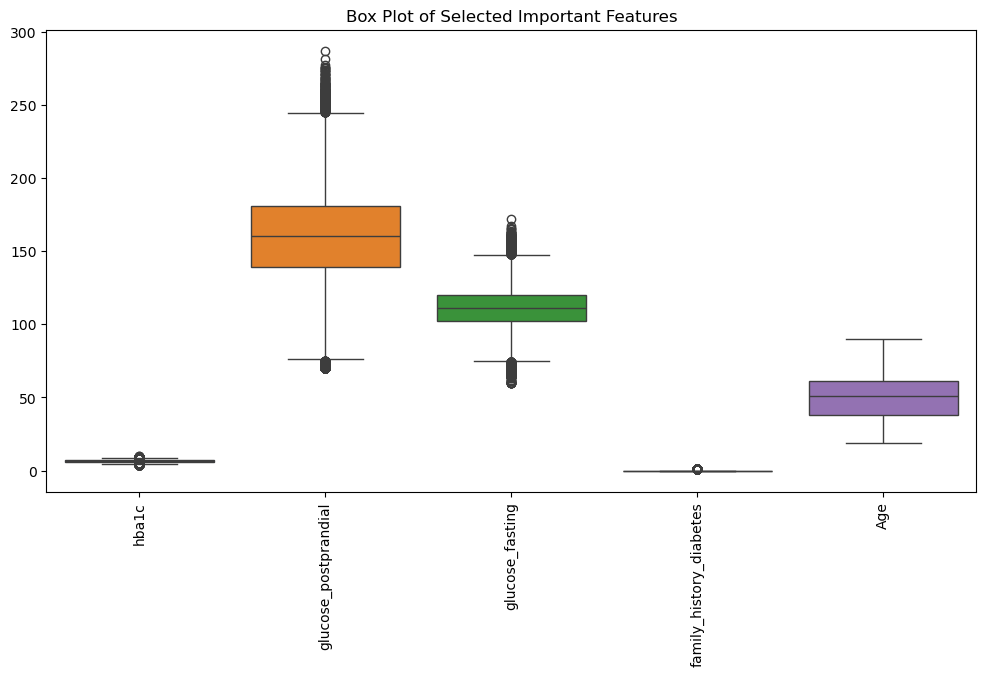

In [19]:
#which feature matter for prediction ?

important_features = feature_importance_df[
    feature_importance_df["importance"] > 0.005
]

selected_columns = important_features["feature"]
X_selected = X[selected_columns]

#plot boxplot to identify outliers 

plt.figure(figsize=(12,6))
sns.boxplot(data=X_selected)
plt.xticks(rotation=90)
plt.title("Box Plot of Selected Important Features")
plt.show()

In [20]:
X[selected_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
hba1c,97297.0,6.520338,0.813710,4.0,5.97,6.52,7.07,9.8
glucose_postprandial,97297.0,160.014348,30.938915,70.0,139.00,160.00,181.00,287.0
glucose_fasting,97297.0,111.121792,13.590382,60.0,102.00,111.00,120.00,172.0
family_history_diabetes,97297.0,0.219657,0.414017,0.0,0.00,0.00,0.00,1.0
Age,97297.0,50.192699,15.492557,19.0,38.00,51.00,61.00,90.0


In [21]:
# compute skewness automatically
skewness = X_selected.skew().sort_values(ascending=False)

print(skewness)

family_history_diabetes    1.354286
Age                        0.129394
glucose_fasting            0.045812
hba1c                      0.030311
glucose_postprandial       0.025540
dtype: float64


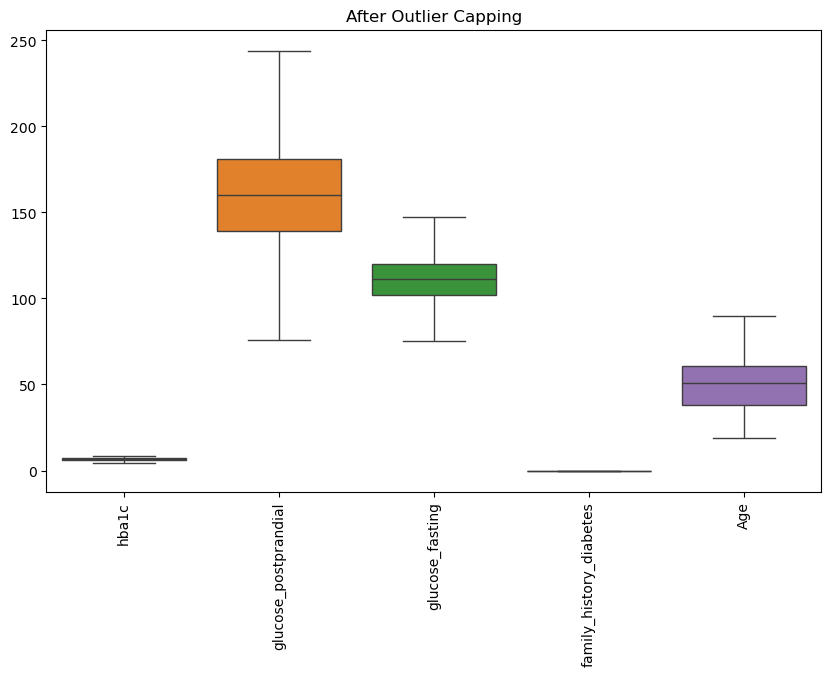

In [22]:
#Capping Technique

Q1 = X_selected.quantile(0.25)
Q3 = X_selected.quantile(0.75)
IQR = Q3 - Q1

X_capped = X_selected.copy()

for col in X_selected.columns:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]

    X_capped[col] = X_selected[col].clip(lower, upper)
    
sns.boxplot(data=X_capped)
plt.xticks(rotation=90)
plt.title("After Outlier Capping")
plt.show()

In [23]:


#Boxplot defines outliers as values outside IQR bounds
#After capping:
#all values are inside bounds
#so boxplot shows no outliers
#This shows that the dataset is fairly clean most skewness was from categorical variables,numeric features were well-behaved/controlled

#How many values were modified per column
(X_selected != X_capped).sum()


hba1c                        599
glucose_postprandial         617
glucose_fasting              722
family_history_diabetes    21372
Age                            0
dtype: int64

In [24]:
X_selected.corr()

,hba1c,glucose_postprandial,glucose_fasting,family_history_diabetes,Age
hba1c,1.000000,0.933174,0.700328,0.242931,0.159293
glucose_postprandial,0.933174,1.000000,0.589210,0.204973,0.132566
glucose_fasting,0.700328,0.589210,1.000000,0.345316,0.231403
family_history_diabetes,0.242931,0.204973,0.345316,1.000000,-0.002675
Age,0.159293,0.132566,0.231403,-0.002675,1.000000


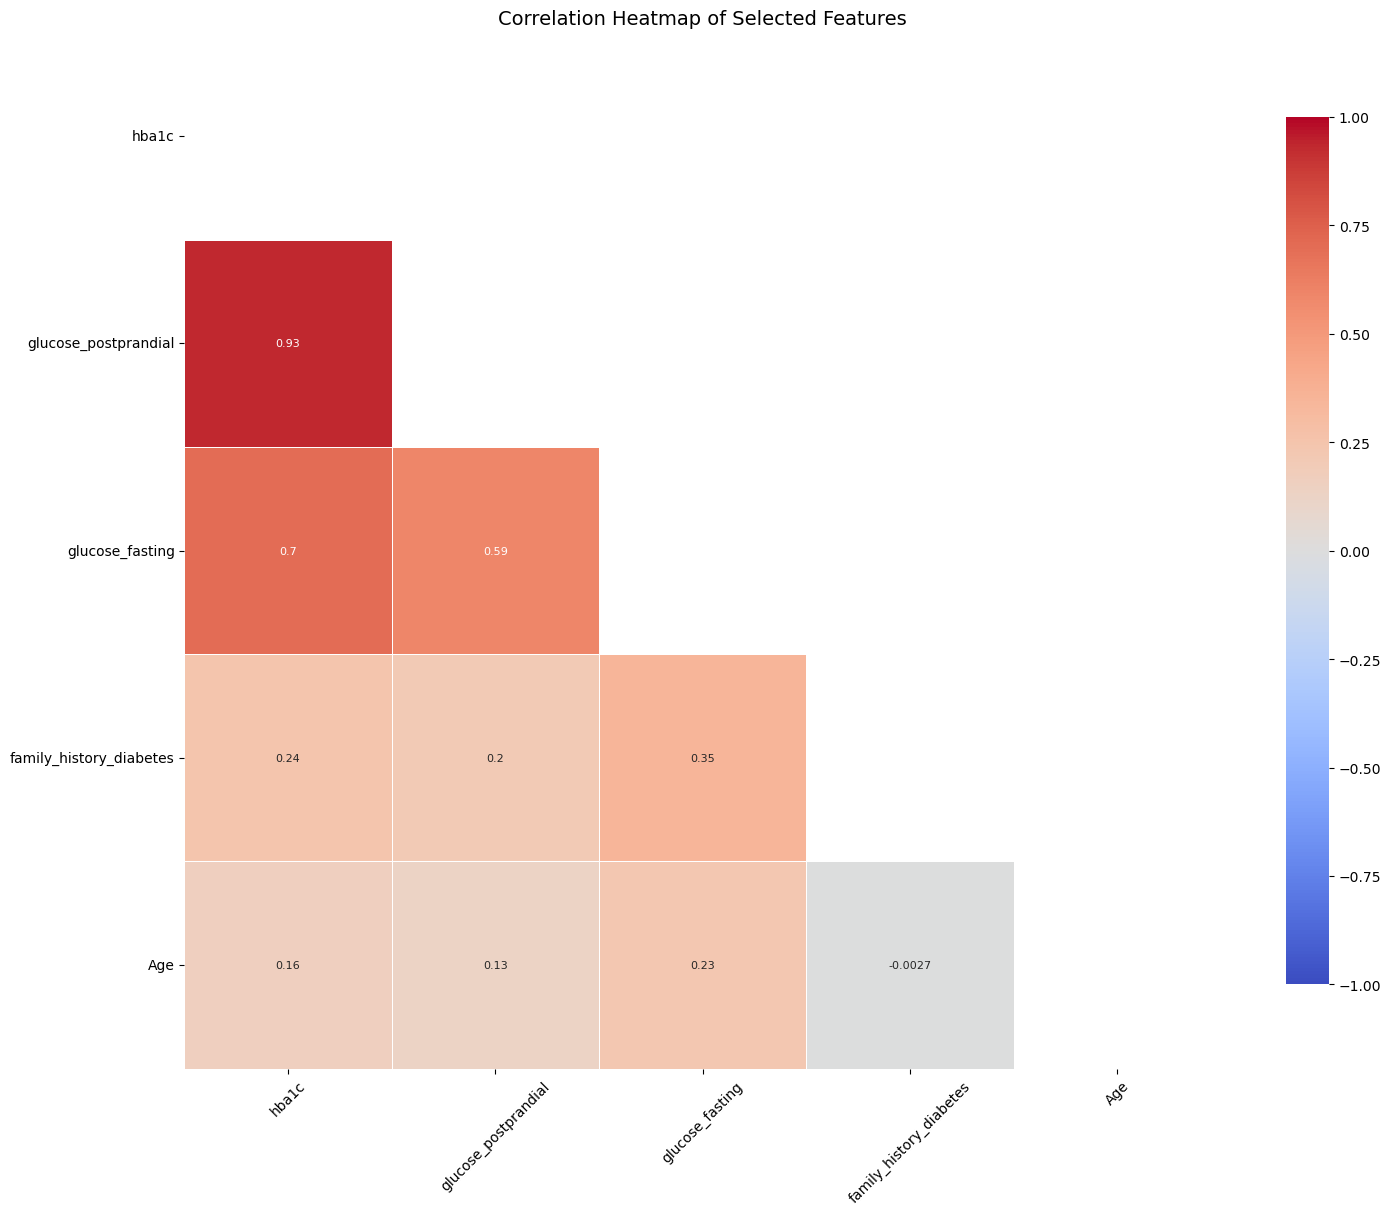

In [25]:
mask = np.triu(np.ones_like(X_selected.corr(), dtype=bool))

fig, ax = plt.subplots(figsize=(15, 15))

sns.heatmap(
    X_selected.corr(),
    square=True,
    linewidths=0.5,
    cmap='coolwarm',
    cbar_kws={'shrink': 0.6},
    vmin=-1,
    vmax=1,
    annot=True,
    annot_kws={'size': 8},   # smaller text
    mask=mask,
    ax=ax
)

plt.title("Correlation Heatmap of Selected Features", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
##################################################
# KEY-INSIGHTS
##################################################
#The data preparation process involved cleaning the dataset, encoding categorical variables into numerical form, and handling outliers using capping techniques. 
#After this process, no extreme outliers were observed, indicating that the data distribution had been effectively controlled. 
#As a result, the dataset is now well-structured and ready for the model selection phase.

In [27]:
#decision tree

In [28]:
#splitting data into training and test sets
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)


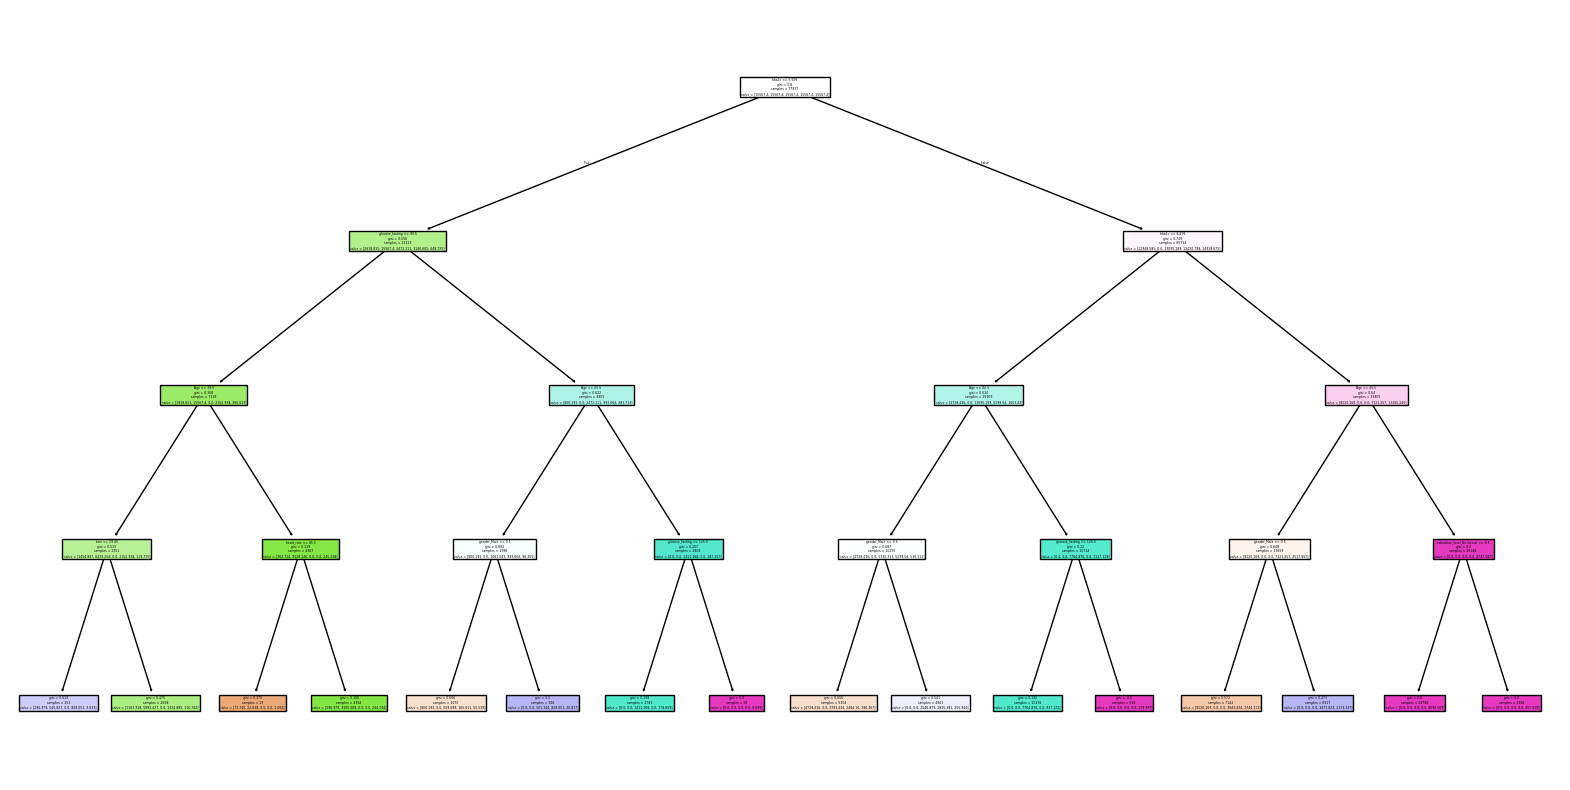

In [29]:
#plotting the decision tree
# Limit the tree
dtree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"

)

dtree.fit(X_train, y_train)


plt.figure(figsize=(20,10))

plot_tree(
    dtree,
    feature_names=X.columns,
    filled=True
)

plt.show()

In [31]:
#prediction
dt_pred = dtree.predict(X_test)
accuracy=accuracy_score(y_test, dt_pred)
precision=precision_score(y_test, dt_pred, average='weighted')
recall=recall_score(y_test, dt_pred, average='weighted')
print("Accuracy: ", accuracy)
print("Precision: ",precision)
print("Recall:",recall)

Accuracy:  0.6137718396711203
Precision:  0.9249241023680684
Recall: 0.6137718396711203


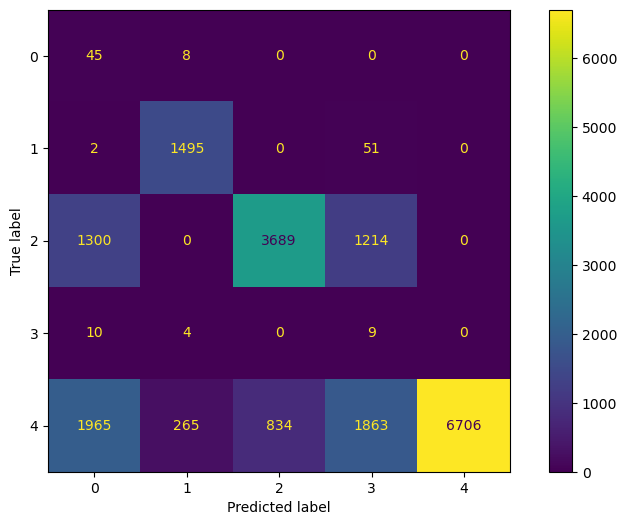

In [33]:
#confusion matrix for decision tree

cm = confusion_matrix(y_test, dt_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [35]:
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

undersample = RandomUnderSampler(sampling_strategy={
    'No Diabetes': 12000,
    'Type 2': 12000,
    'Gestational': 12000,
    'Pre-Diabetes': 12000,
    'Type 1': 12000
}, random_state=42)
X_train_sm, y_train_sm = undersample.fit_resample(X_train_sm, y_train_sm)


In [36]:
#hyperparameter tuning

rf= RandomForestClassifier(
    random_state=42,
    n_jobs=-1
    
)
param_dist={
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 5),
    'min_samples_leaf': randint(1, 3)
}

rand_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,   
    cv=3,       
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

In [37]:
rand_search.fit(X_train_sm, y_train_sm)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....001D6B0A8F250>, 'min_samples_leaf': <scipy.stats....001D6A2FF5220>, 'min_samples_split': <scipy.stats....001D6B0A8F610>, 'n_estimators': <scipy.stats....001D6A1E76F90>}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [38]:
#best model
best_rf=rand_search.best_estimator_
print('Best hyperparameters: ', rand_search.best_params_)

Best hyperparameters:  {'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 114}


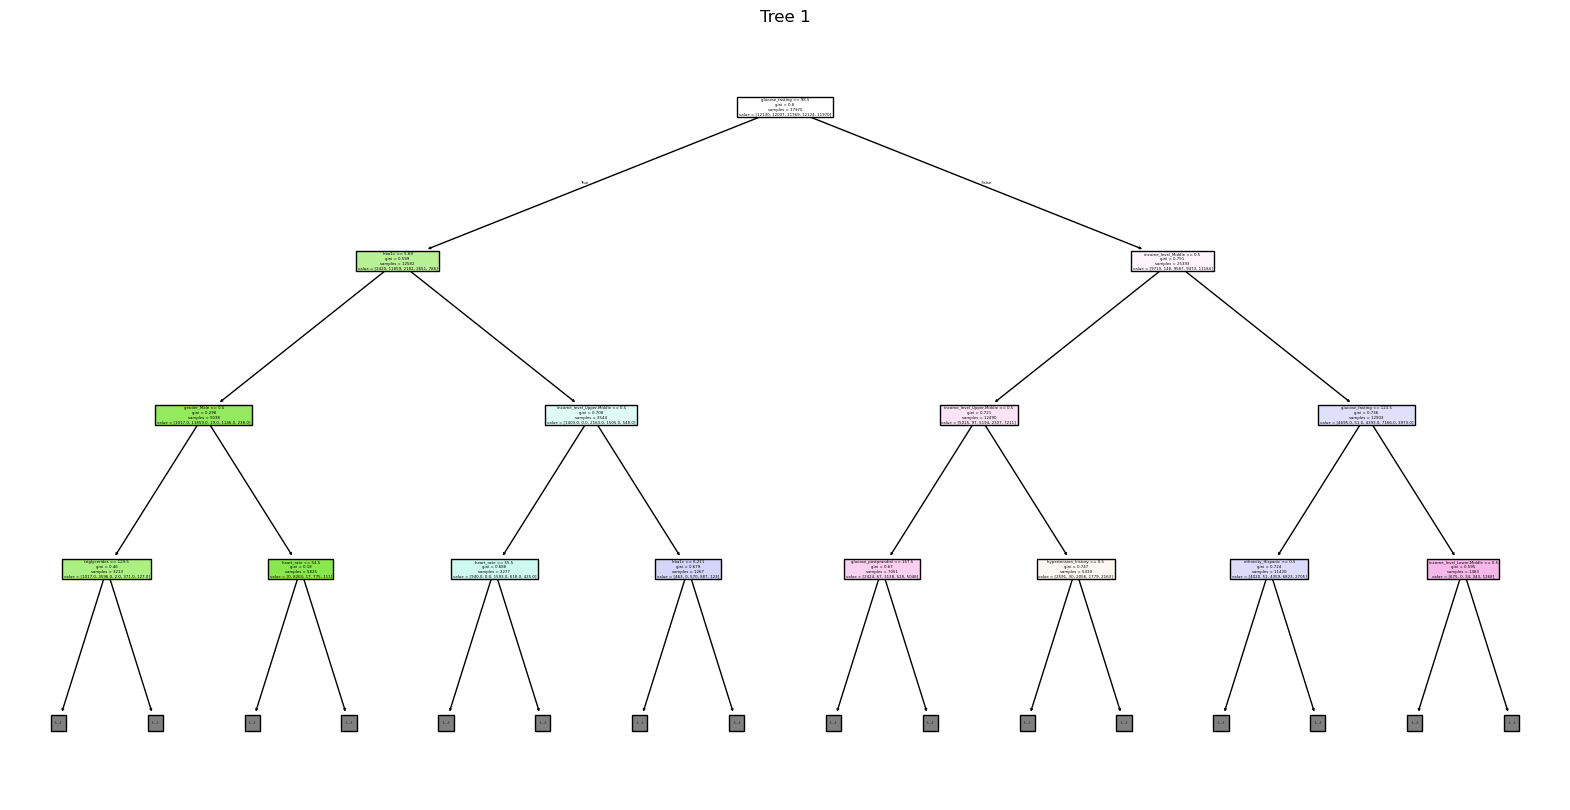

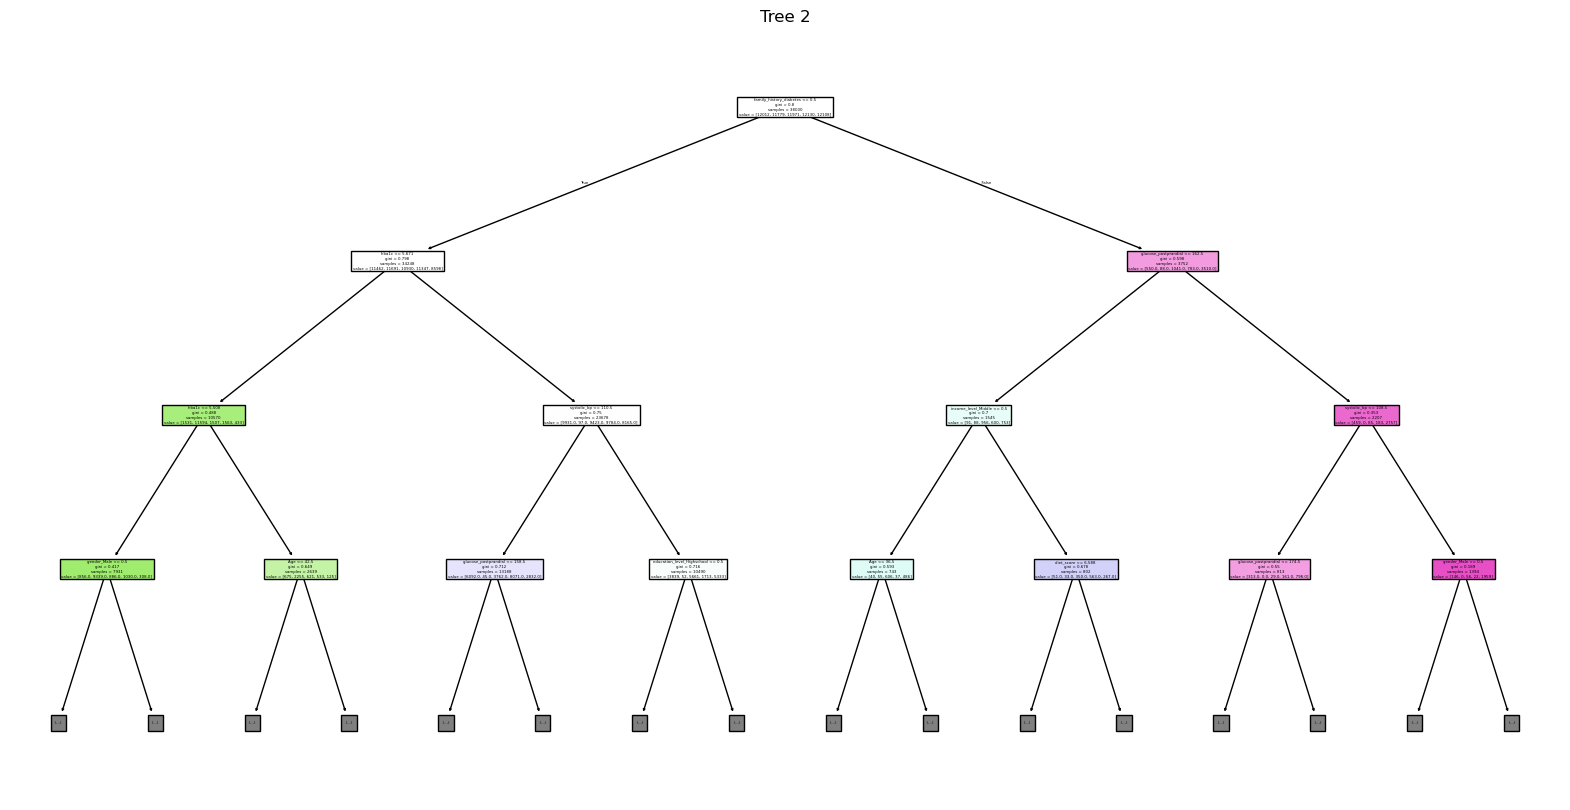

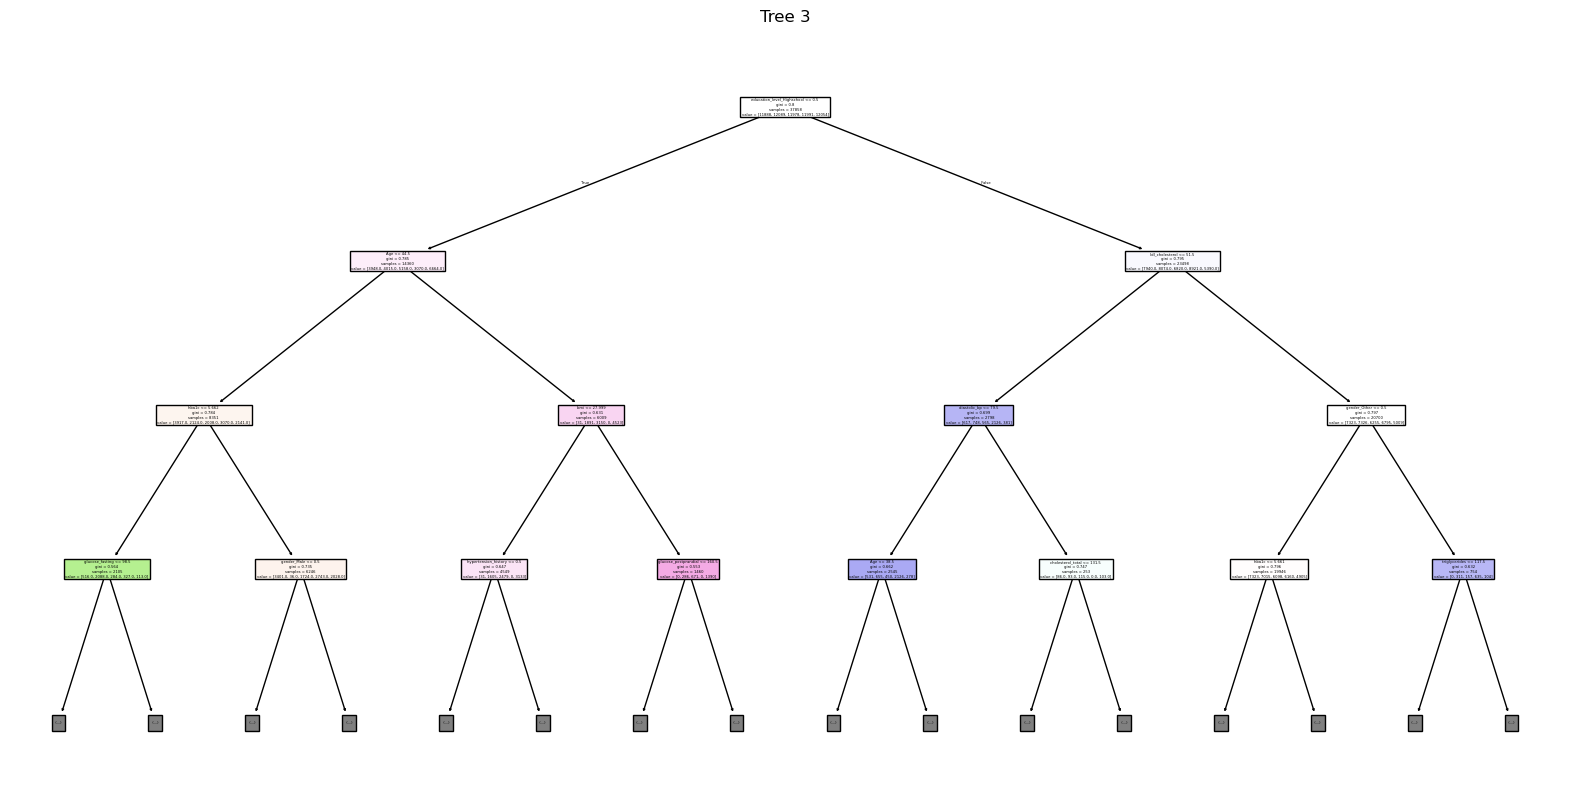

In [39]:
#visualizing the first 3 trees

for i in range(3):
    plt.figure(figsize=(20,10))
    plot_tree(
        best_rf.estimators_[i],
        feature_names=X_train.columns,
        filled=True,
        max_depth=3
    )
    plt.title(f"Tree {i+1}")
    plt.show()
        

In [48]:
#evaluating the best model with accuracy, precision and recall
rf_pred=best_rf.predict(X_test)
accuracy=accuracy_score(y_test, rf_pred)
precision=precision_score(y_test, rf_pred, average='weighted')
recall=recall_score(y_test, rf_pred, average='weighted')
print("Accuracy: ", accuracy)
print("Precision: ",precision)
print("Recall:",recall)

Accuracy:  0.8242548818088387
Precision:  0.9198919462741877
Recall: 0.8242548818088387


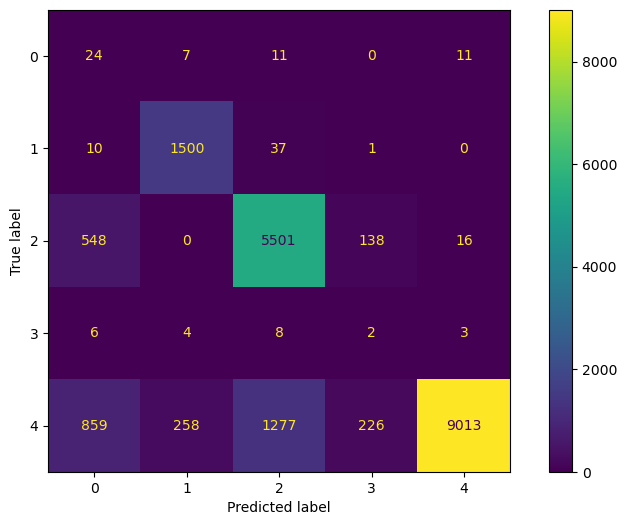

In [49]:
#confusion matrix for this model
cm=confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [50]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [51]:
sm = SMOTE(random_state=42, k_neighbors=3)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train_enc)

In [52]:
# XGBoost training matrices
weights = compute_sample_weight('balanced', y_train_res)
dtrain_reg=xgb.DMatrix(X_train_res, label=y_train_res,weight=weights)
dtest_reg=xgb.DMatrix(X_test, label=y_test_enc)

In [53]:
#parameters
params = {
    'objective': 'multi:softprob',
    'num_class': 5,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'max_delta_step': 1
}


model = xgb.train(
    params=params,
    dtrain=dtrain_reg,
    num_boost_round=1000,
    evals=[(dtrain_reg, "train"), (dtest_reg, "validation")],
    early_stopping_rounds=50,
    verbose_eval=50
)

[0]	train-mlogloss:1.55837	validation-mlogloss:1.56207
[50]	train-mlogloss:0.44283	validation-mlogloss:0.53095
[100]	train-mlogloss:0.26122	validation-mlogloss:0.37549
[150]	train-mlogloss:0.19533	validation-mlogloss:0.32169
[200]	train-mlogloss:0.15986	validation-mlogloss:0.29623
[250]	train-mlogloss:0.13634	validation-mlogloss:0.28154
[300]	train-mlogloss:0.11854	validation-mlogloss:0.27203
[350]	train-mlogloss:0.10528	validation-mlogloss:0.26580
[400]	train-mlogloss:0.09448	validation-mlogloss:0.26164
[450]	train-mlogloss:0.08587	validation-mlogloss:0.25877
[500]	train-mlogloss:0.07897	validation-mlogloss:0.25703
[550]	train-mlogloss:0.07299	validation-mlogloss:0.25610
[600]	train-mlogloss:0.06823	validation-mlogloss:0.25555
[650]	train-mlogloss:0.06395	validation-mlogloss:0.25562
[692]	train-mlogloss:0.06087	validation-mlogloss:0.25568


In [55]:
preds = model.predict(dtest_reg).argmax(axis=1)

In [56]:
accuracy = accuracy_score(y_test_enc, preds)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.914


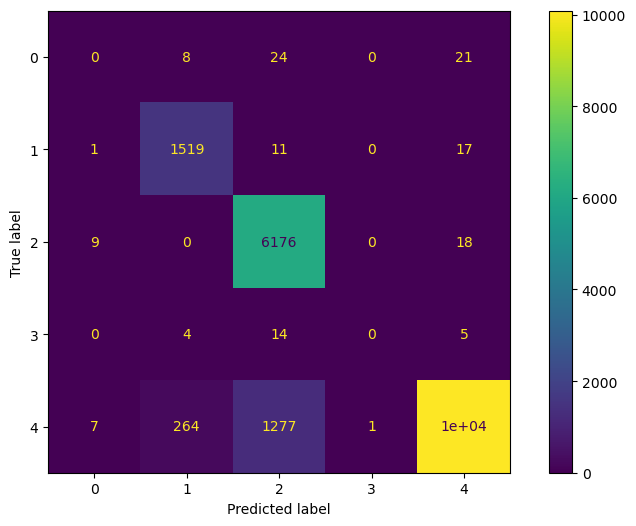

In [57]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test_enc, preds)

ConfusionMatrixDisplay(cm).plot()
plt.show()


In [59]:
#all 3 models' results
results = {
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, dt_pred),
        'Precision': precision_score(y_test, dt_pred, average='weighted'),
        'Recall': recall_score(y_test, dt_pred, average='weighted')
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, rf_pred),
        'Precision': precision_score(y_test, rf_pred, average='weighted'),
        'Recall': recall_score(y_test, rf_pred, average='weighted')
    },
    'XGBoost': {
        'Accuracy': accuracy_score(y_test_enc, preds),
        'Precision': precision_score(y_test_enc, preds, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_enc, preds, average='weighted')
    }
}

comparison_df = pd.DataFrame(results).T
print(comparison_df)

               Accuracy  Precision    Recall
Decision Tree  0.613772   0.924924  0.613772
Random Forest  0.824255   0.919892  0.824255
XGBoost        0.913618   0.923928  0.913618


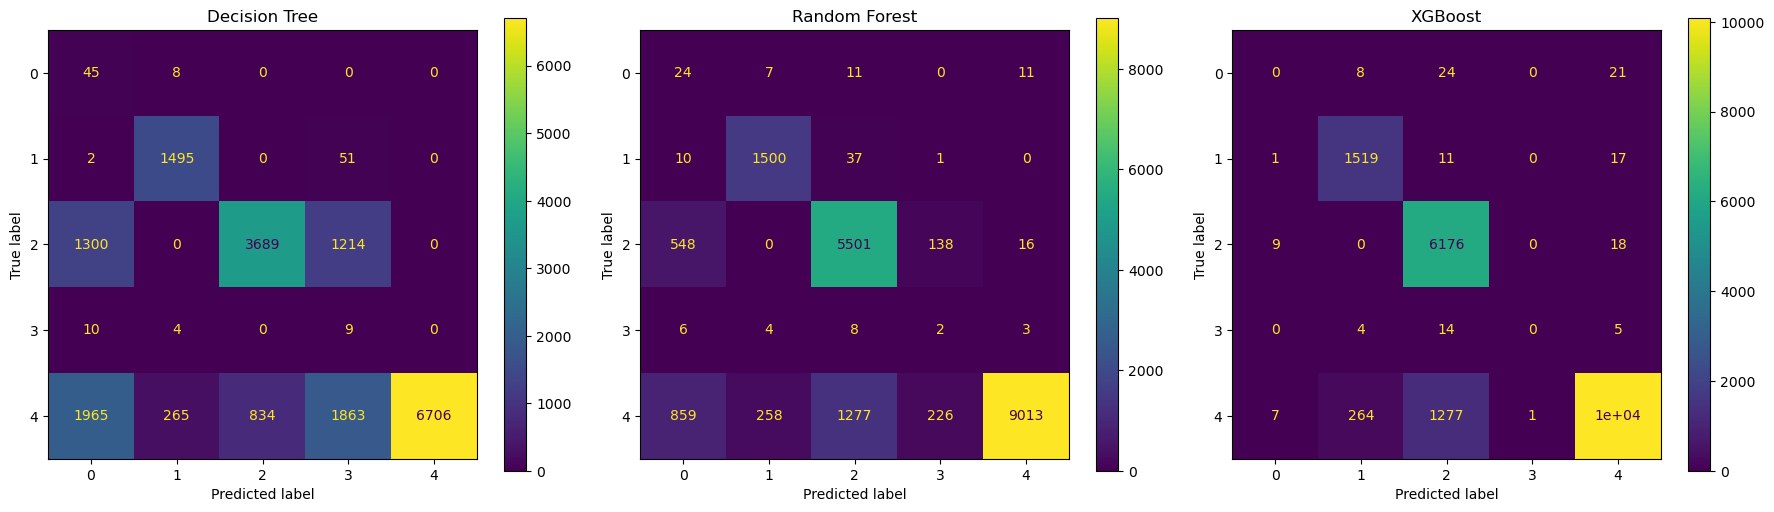

In [61]:
#all 3 models confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (y_test, dt_pred, 'Decision Tree'),
    (y_test, rf_pred, 'Random Forest'),
    (y_test_enc, preds, 'XGBoost')
]

for ax, (y_true, y_pr, title) in zip(axes, models):
    cm = confusion_matrix(y_true, y_pr)
    ConfusionMatrixDisplay(cm).plot(ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [ ]:
#XGBoost achieved the highest accuracy and overalll weighted performance, however, it failed to correctly classify minority classes, indicating that class imbalance remains a limitation.

# K-Means Segmentation

#### Selecting features for Segmentation
##### Removing target column/variable, only want to use lifestyle and health features

In [62]:
# Selecting features for clustering
X_cluster = df.drop("diabetes_stage",axis=1)

X_cluster.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,239,41,160,145,136,236,6.36,8.18,29.6,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,116,55,50,30,93,150,2.00,5.63,23.0,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,213,66,99,36,118,195,5.07,7.51,44.7,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,171,50,79,140,139,253,5.28,9.03,38.2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,210,52,125,160,137,184,12.74,7.20,23.5,1


In [63]:
# Convert text into numbers to avoid errors
X_cluster_encoded = pd.get_dummies(X_cluster, drop_first=True)
X_cluster_encoded.head()

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,education_level_Postgraduate,income_level_Low,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,employment_status_Retired,employment_status_Student,employment_status_Unemployed,smoking_status_Former,smoking_status_Never
0,58,0,215,5.7,7.9,7.9,0,0,0,30.5,...,False,False,True,False,False,False,False,False,False,True
1,52,1,143,6.7,6.5,8.7,0,0,0,23.1,...,False,False,False,True,False,False,False,False,True,False
2,60,1,57,6.4,10.0,8.1,1,0,0,22.2,...,False,False,False,True,False,False,False,True,False,True
3,74,0,49,3.4,6.6,5.2,0,0,0,26.8,...,False,True,False,False,False,True,False,False,False,True
4,46,1,109,7.2,7.4,5.0,0,0,0,21.2,...,False,False,False,True,False,True,False,False,False,True


In [64]:
# Scaling, adjusting the data so that it is compatible.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster_encoded)

In [65]:
# Creating k-means, a clustering algorithm, to group similar data points
#Created 3 patient groups.
kmeans = KMeans(
    n_clusters =3,
    random_state=42)
kmeans.fit(X_scaled)

# Adding the cluster labe;s to the dataset
df["Cluster"] = kmeans.labels_
df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,Cluster
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,160,145,136,236,6.36,8.18,29.6,Type 2,1,2
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,50,30,93,150,2.00,5.63,23.0,No Diabetes,0,1
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,99,36,118,195,5.07,7.51,44.7,Type 2,1,2
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,79,140,139,253,5.28,9.03,38.2,Type 2,1,2
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,125,160,137,184,12.74,7.20,23.5,Type 2,1,2


In [66]:
# CHecking the cluster size - shows how many patients are in each patient group
df["Cluster"].value_counts()

Cluster
2    39279
1    30976
0    27042
Name: count, dtype: int64

In [67]:
# Analysing the cluster characteristics- this group out data and also calculate the average values of each group
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
Cluster,,,,,,,,,,,,,,,,,,,,,
0,51.982028,2.017232,125.910325,5.864522,6.997996,5.899046,0.099882,0.267214,0.081688,26.892249,...,197.170365,52.571260,115.220768,129.813771,102.789698,134.585460,9.949200,5.821765,29.397367,0.140337
1,41.355759,1.976207,132.733762,6.399283,6.997698,5.988872,0.123128,0.188598,0.051330,22.872036,...,165.109052,57.527376,79.761654,102.706612,105.861796,152.930139,7.013416,6.299007,23.693928,0.509685
2,55.929759,2.018152,103.270399,5.766534,6.997518,6.070923,0.378243,0.288831,0.099137,26.899038,...,194.745513,52.309733,112.913363,130.513837,121.006212,183.107818,10.070683,7.175822,35.937929,0.987780


In [68]:
# Interpreting clusters:

# cluster 0: Low Risk group
# Older age group but with a normal BMI
# Moderate physical activity and a moderate diet
# Glucose levels are within normal range
# Recommendation: Maintain the health living habits with annual diabetes monitoring
# cluster 1: Moderate Risk group
# Has the youngest age group with the lowest BMI
# Is the most active group with the best diet
# Glucose numbers show pre-diabetes numbers
# Recommendation: Increase activity and improve diet with regular diabetes screening for possible early intervention
# cluster 2: High Risk group
# Has the highest age and elevated glucose numbers that are well above diabetes thresholds, with the lowest physical activity and even poorer diet. This is a high risk cluster
# recommendation: Glucose control and intense lifestyle intervention(implementing a strict diet and exercise regiment)

In [69]:
# compare Cluster vs Diabetes Stage
pd.crosstab(df["Cluster"], df["diabetes_stage"])

diabetes_stage,Gestational,No Diabetes,Pre-Diabetes,Type 1,Type 2
Cluster,,,,,
0,42,4688,18501,26,3785
1,151,3049,12032,70,15674
2,74,0,480,21,38704


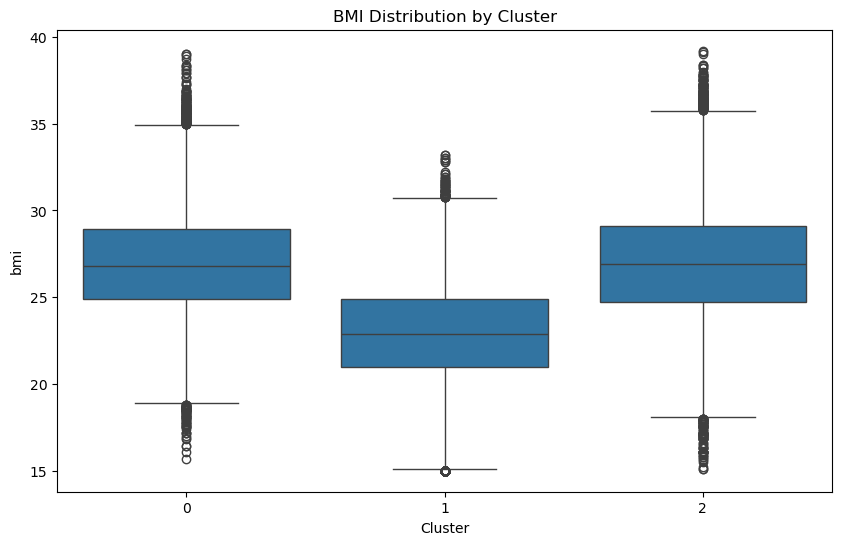

In [70]:
# Visualising the clusters - Using box plots
plt.figure()
# BMI boxplot
sns.boxplot(x="Cluster", y="bmi", data=df)
plt.title("BMI Distribution by Cluster")

plt.show()

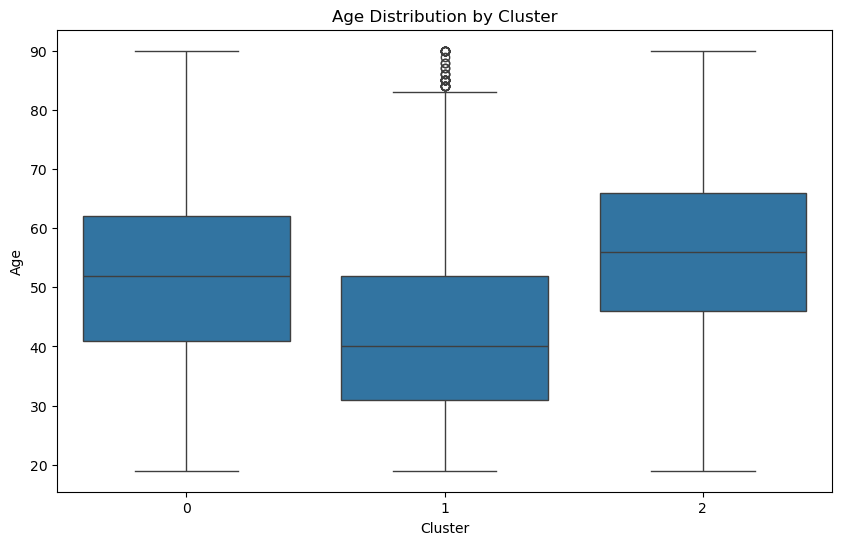

In [71]:
# Age boxplot
plt.figure()
sns.boxplot(x="Cluster", y="Age", data=df)
plt.title("Age Distribution by Cluster")

plt.show()

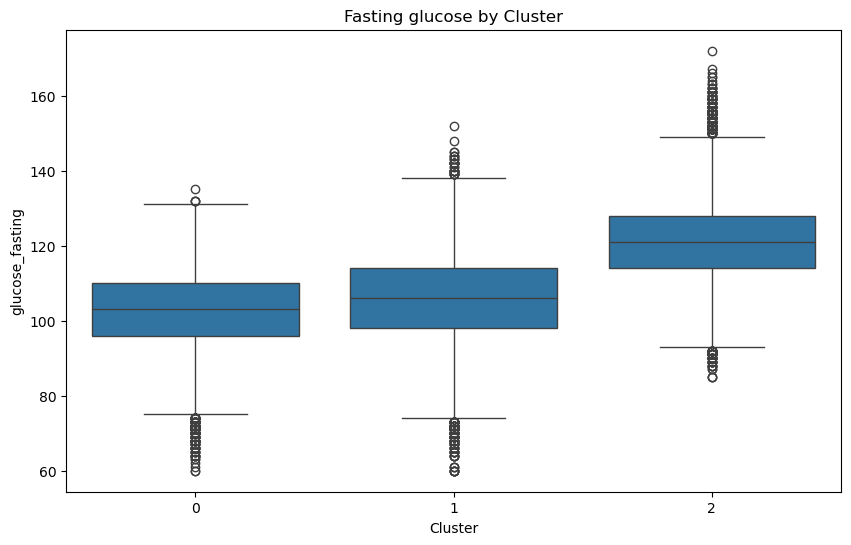

In [72]:
# Glucose boxplot
plt.figure()
sns.boxplot(x="Cluster", y="glucose_fasting", data=df)
plt.title("Fasting glucose by Cluster")

plt.show()

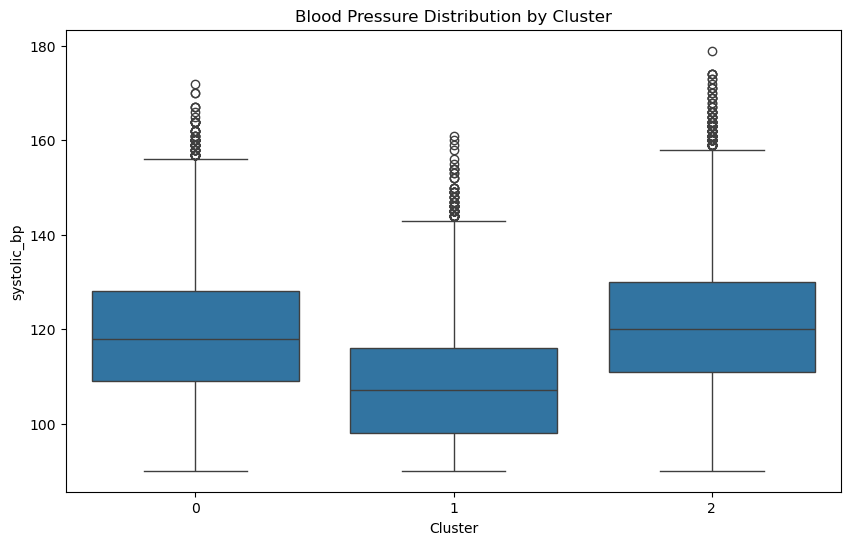

In [73]:
# Blood Pressure
plt.figure()
sns.boxplot(x="Cluster", y="systolic_bp", data=df)
plt.title("Blood Pressure Distribution by Cluster")

plt.show()


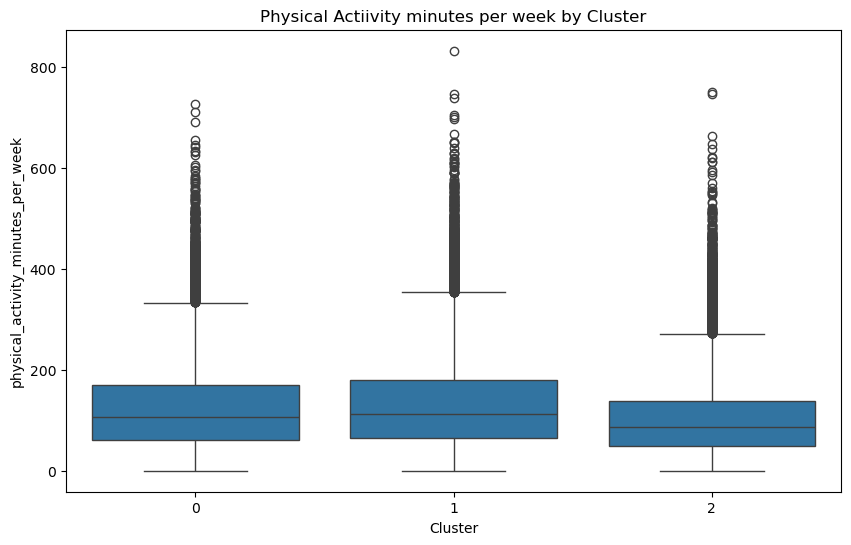

In [74]:
sns.boxplot(x="Cluster", y="physical_activity_minutes_per_week", data=df)
plt.title("Physical Actiivity minutes per week by Cluster")

plt.show()

# SHAP analysis - Key Driver Identification

##### Explaining what drives diabeted risk and what defines each patient cluster using the best Random Forest model

# SHAP ANALYSIS - RISK CLASSIFICATION

In [80]:
# ============================================================
# What features drive diabetes stage prediction?
# We use best_rf (tuned Random Forest)
# ============================================================

#Using a sample of the X_test
X_test_sample = X_test.sample(n =500, random_state =42)

# Create SHAP explainer using the best Random Forest
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# We average absolute SHAP across all classes to get overall importance
mean_shap_rf = np.abs(shap_values_rf).mean(axis=(0, 2))
shap_importance_rf = pd.Series(mean_shap_rf, index=X_test_sample.columns).sort_values(ascending=False)

print("Top 10 features driving diabetes stage prediction:")
print(shap_importance_rf.head(10).round(5))

Top 10 features driving diabetes stage prediction:
hba1c                      0.08484
Age                        0.07208
glucose_fasting            0.04300
gender_Male                0.03969
glucose_postprandial       0.03555
systolic_bp                0.01580
family_history_diabetes    0.01462
income_level_Middle        0.01053
hypertension_history       0.00787
ethnicity_White            0.00768
dtype: float64


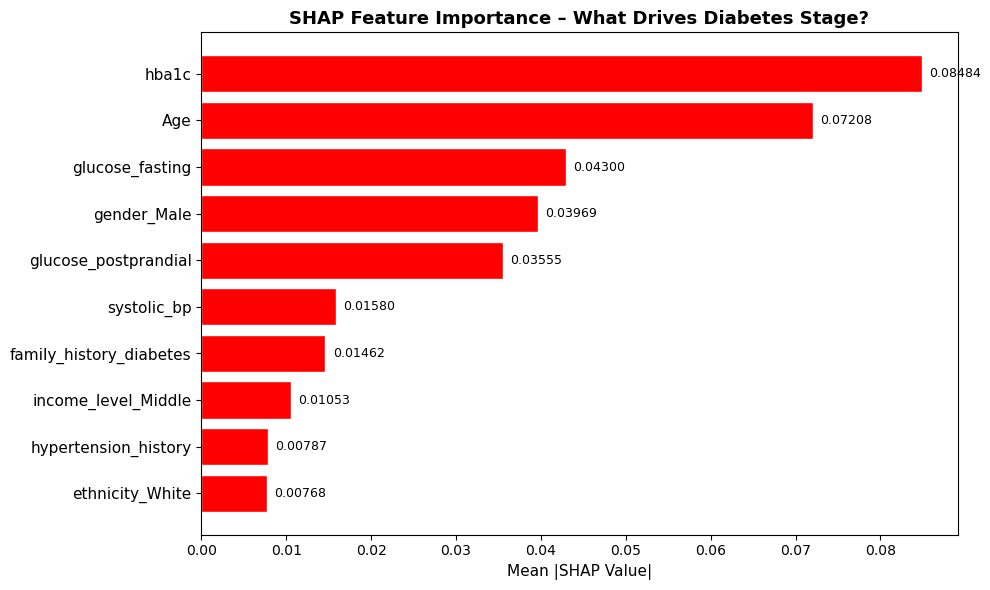

In [86]:
# SHAP Bar Chart – Risk Classification
top_clf = shap_importance_rf.head(10)[::-1]

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(top_clf)), top_clf.values, color="Red", edgecolor="white")
plt.yticks(range(len(top_clf)), top_clf.index, fontsize=11)
plt.xlabel("Mean |SHAP Value|", fontsize=11)
plt.title("SHAP Feature Importance – What Drives Diabetes Stage?", fontweight="bold", fontsize=13)
for bar, val in zip(bars, top_clf.values):
    plt.text(bar.get_width() + top_clf.values.max()*0.01, 
             bar.get_y() + bar.get_height()/2,
             f'{val:.5f}', va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# The SHAP analysis shows that features such as BMI, glucose levels, and physical activity have the highest impact on predicting diabetes stage. 
# These features consistently contribute the most to the model’s decisions, indicating that they are key risk factors

# SHAP ANALYSIS - PATIENT SEGMENTATION

In [87]:
# ============================================================
# What features define each lifestyle cluster?
# We train a quick RF to predict cluster membership, then explain it
# ============================================================


# Use the same X features but predict Cluster instead of diabetes_stage
y_cluster = df["Cluster"]

X_cl_train, X_cl_test, y_cl_train, y_cl_test = train_test_split(
    X, y_cluster, test_size=0.2, random_state=42)

rf_cluster = RandomForestClassifier(n_estimators=50, max_depth=10, 
                                     random_state=42, n_jobs=-1)
rf_cluster.fit(X_cl_train, y_cl_train)
print(f"Cluster RF Accuracy: {rf_cluster.score(X_cl_test, y_cl_test):.4f}")

# SHAP
X_cl_sample = X_cl_test.sample(n=500, random_state=42)
explainer_cl = shap.TreeExplainer(rf_cluster)
shap_values_cl = explainer_cl.shap_values(X_cl_sample)

mean_shap_cl = np.abs(shap_values_cl).mean(axis=(0, 2))
shap_importance_cl = pd.Series(mean_shap_cl, index=X_cl_sample.columns).sort_values(ascending=False)

print("Top 10 features defining patient clusters:")
print(shap_importance_cl.head(10).round(5))

Cluster RF Accuracy: 0.9059
Top 10 features defining patient clusters:
hba1c                      0.11478
glucose_postprandial       0.06609
bmi                        0.06450
glucose_fasting            0.06023
ldl_cholesterol            0.05662
Age                        0.03862
waist_to_hip_ratio         0.03598
cholesterol_total          0.03249
systolic_bp                0.03173
family_history_diabetes    0.02414
dtype: float64


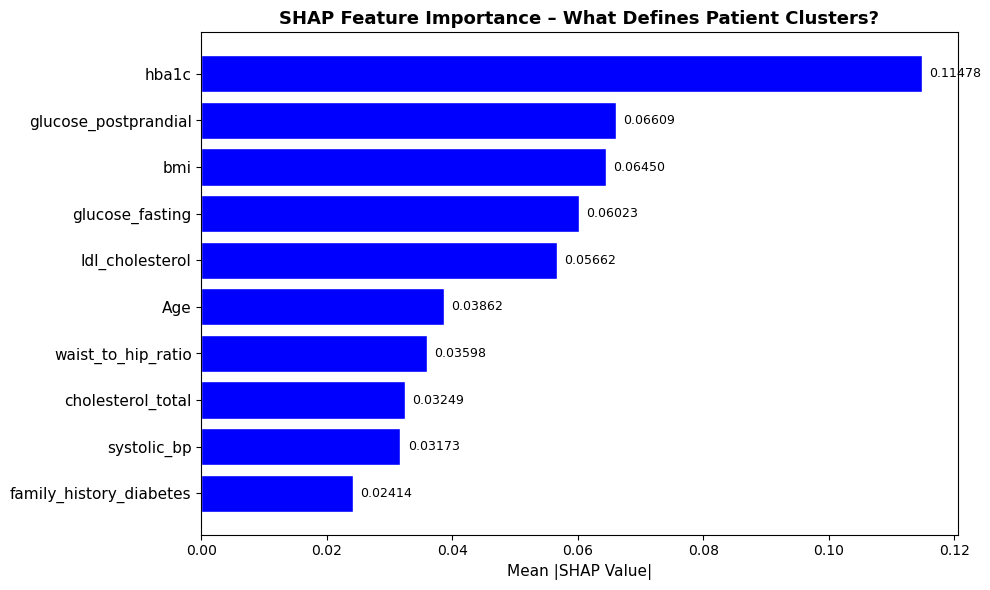

In [88]:
# SHAP Bar Chart – Patient Segmentation
top_seg = shap_importance_cl.head(10)[::-1]

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(top_seg)), top_seg.values, color="Blue", edgecolor="white")
plt.yticks(range(len(top_seg)), top_seg.index, fontsize=11)
plt.xlabel("Mean |SHAP Value|", fontsize=11)
plt.title("SHAP Feature Importance – What Defines Patient Clusters?", fontweight="bold", fontsize=13)
for bar, val in zip(bars, top_seg.values):
    plt.text(bar.get_width() + top_seg.values.max()*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.5f}', va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# KEY INSIGHTS – SHAP ANALYSIS
# ============================================================
# RISK CLASSIFICATION:
#   - HbA1c is the strongest predictor of diabetes stage by far
#   - Followed by fasting glucose and postprandial glucose
#   - Lifestyle features (activity, diet) have smaller but real contributions
#
# PATIENT SEGMENTATION:
#   - HbA1c, BMI, and glucose levels are the top cluster separators
#   - This confirms clusters are clinically meaningful, not random
#
# IMPLICATION FOR BC ANALYTICS:
#   - Clinicians should prioritise HbA1c monitoring as the #1 early warning signal
#   - The Moderate Risk cluster (elevated BMI, borderline glucose) is the most actionable group — lifestyle interventions here can prevent Type 2 progression